In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.shape

(32581, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [6]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [7]:
#Checking the class of loan_status
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

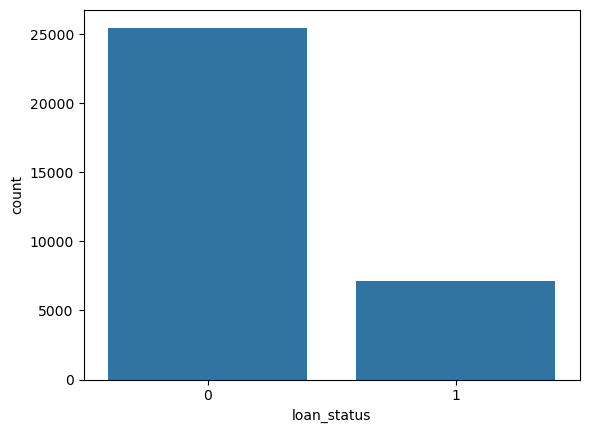

In [8]:
sns.countplot(x='loan_status',data=df)

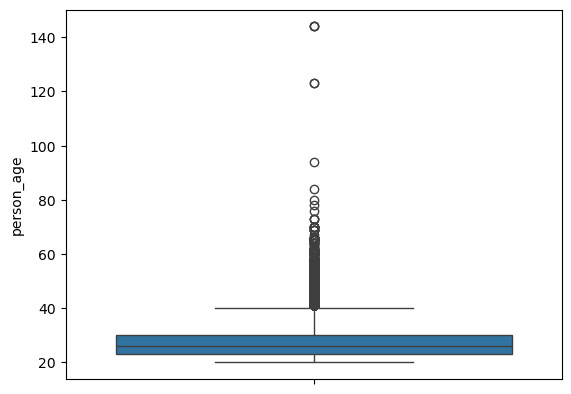

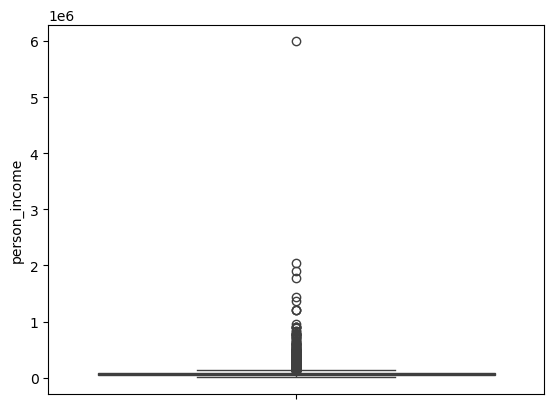

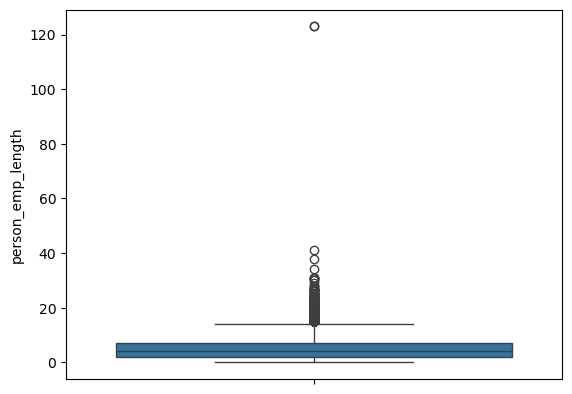

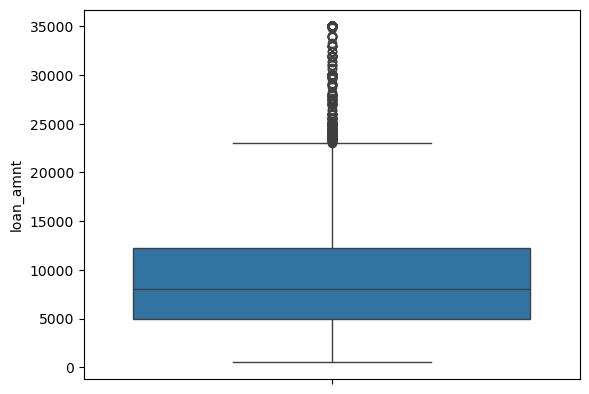

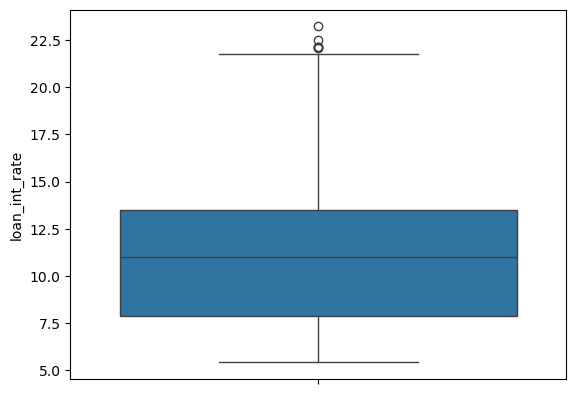

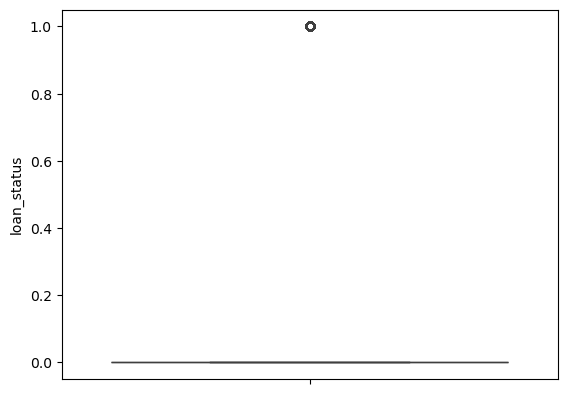

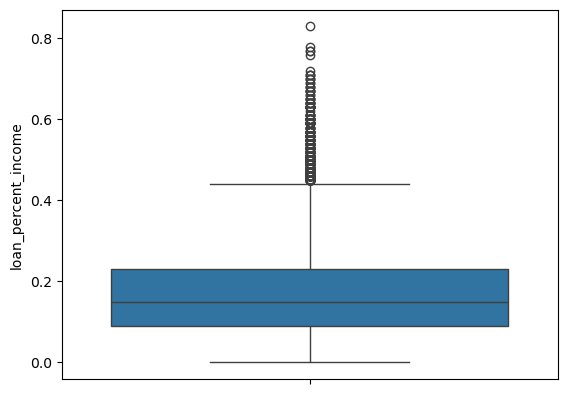

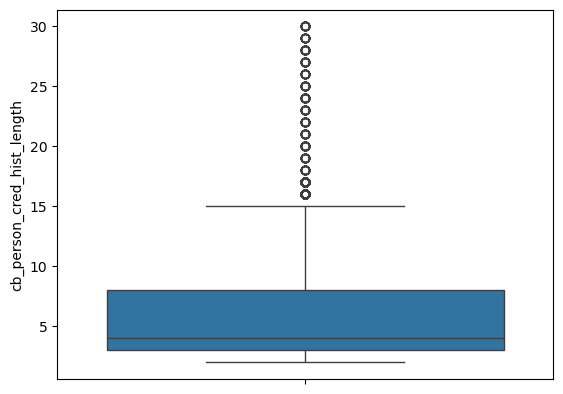

In [9]:
num1_cols = df.select_dtypes(include=np.number).columns

for i in num1_cols:
    sns.boxplot(y=df[i])
    plt.show()

In [10]:
(df['person_age'] > 100).sum()

np.int64(5)

In [11]:
(df["person_emp_length"] > 60).sum()

np.int64(2)

<Axes: >

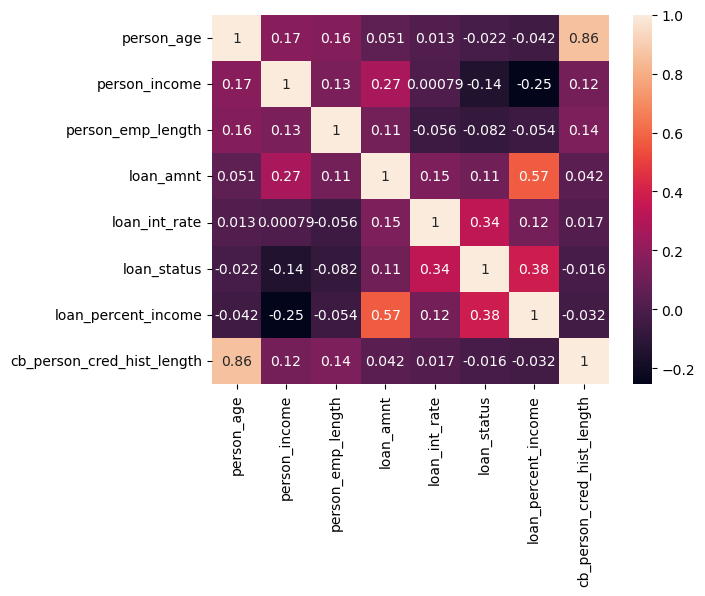

In [12]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [13]:
df1 = df.copy()
print(f'Original Rows: {df1.shape[0]}')

#Remove duplicate rows:
df1.drop_duplicates(inplace=True)
print(f'New Rows: {df1.shape[0]}')

#Remove unreal ages [age<18 or age>100]
df1 = df1[df1['person_age'] >= 18]
df1 = df1[df1['person_age'] <= 100]

#Remove emp_len > age or extreme outliers(>60)
df1 = df1[df1['person_emp_length'] <= df1['person_age']]
df1 = df1[df1['person_emp_length'] <= 60]

#Remove loan_amount which is (<=0)
df1 = df1[df1['loan_amnt'] > 0]

Original Rows: 32581
New Rows: 32416


In [14]:
X = df1.drop('loan_status',axis=1)
y = df1['loan_status']

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42,stratify=y)

In [16]:
print(df1.select_dtypes(include=np.number).columns)
print(df1.select_dtypes(include=['category', 'object']).columns)

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='object')
Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')


In [17]:
num_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate','loan_percent_income',
       'cb_person_cred_hist_length']
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file']

In [18]:
#Class
#0-> no loan
#1-> yes loan
neg,pos = np.bincount(y_train)
scale_weights = neg/pos
scale_weights

np.float64(3.630344222758167)

In [19]:
#Logistic Regression: impute + SCALE Numeric,impute + OneHotEncoding
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

#Pipeline: Num Cols::
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num',Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler',StandardScaler())
        ]),num_cols),
        
#Pipeline: Cat Cols::        
        ('cat',Pipeline([
             ('imputer',SimpleImputer(strategy='constant',fill_value='Missing')),
            ('encoder',OneHotEncoder(handle_unknown='ignore'))
        ]),cat_cols)
    ])

In [20]:
#XGBoost: Impute numeric only (No Scaling) , impute + OneHotEncoding

#Pipeline: Num Cols::
preprocessor_xg = ColumnTransformer(
    transformers=[
        ('num',Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
              ]),num_cols),

#Pipeline: Cat Cols::              
        ('cat',Pipeline([
             ('imputer',SimpleImputer(strategy='constant',fill_value='Missing')),
            ('encoder',OneHotEncoder(handle_unknown='ignore'))
        ]),cat_cols)
    ])

In [48]:
# We have to evaluate Logistic and XGBoost model on the basics of their matrices
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,precision_score,recall_score,classification_report,precision_recall_curve
def evaluate_model(model_name,model,X_test,y_test,threshold=None):
    y_pred_prob = model.predict_proba(X_test)[:,1]

    if threshold:
        y_pred = (y_pred_prob > threshold).astype(int)
    else:
        y_pred = model.predict(X_test)

#Metrices:
    accuracy_s = accuracy_score(y_test,y_pred) #Overall Performance
    precision_s = precision_score(y_test,y_pred) #Of the ones I picked,how mny were actually right?
    recall_s = recall_score(y_test,y_pred) #Out of everything that was really there,how much did u manage to find?
    f1 = f1_score(y_test,y_pred) #Harmonic mean of precision and recall
    
#Confusion Matrix:
    cm = confusion_matrix(y_test,y_pred)
    class_report = classification_report(y_test,y_pred)
    
    print((f'{model_name} Metrices'))
    print(f'Thresholds: {best_threshold}')
    print(f'Accuracy: {accuracy_s:.2f}')
    print(f'Recall: {recall_s:.2f}')
    print(f'Precision: {precision_s:.2f}')
    print(f'F1: {f1:.2f}')
    print()
    print(f'{model_name} Classification Report:')
    print(class_report)

#Plotting Confusion Matrix:
    sns.heatmap(cm,annot=True,fmt='d')
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('Actual values')
    plt.xlabel('Predicted values')
    plt.show()

#Plotting ROC-AUC curve:
    precisions,recalls,threshold = precision_recall_curve(y_test,y_pred_prob)
    plt.plot(recalls,precisions)
    plt.title(f'{model_name} Precision-Recall')
    plt.ylabel('Precision')
    plt.xlabel('Recall')
    plt.show()

In [22]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'roc_auc': 'roc_auc', 'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'}

In [23]:
#Logistic Regression: 

from sklearn.linear_model import LogisticRegression
lr_cv_pip = Pipeline([
    ('preprocessor',preprocessor_lr),
    ('classifier',LogisticRegression(max_iter=1000,random_state=42,class_weight='balanced'))
])
lr_cv_pip 

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [24]:
#XGBoost:

from xgboost import XGBClassifier
xg_cv_pip = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        scale_pos_weight=scale_weights, random_state=42
    ))
])
xg_cv_pip

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [25]:
for cv_name, pipe in [('Logistic Regression', lr_cv_pip), ('XGBoost', xg_cv_pip)]:
    cv_results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

    print(cv_name)
    print(f'ROC-AUC: {cv_results['test_roc_auc'].mean()}')
    print(f'Accuracy: {cv_results['test_accuracy'].mean()}')
    print(f'Recall: {cv_results['test_recall'].mean()}')
    print(f'Precision: {cv_results['test_precision'].mean()}')
    print(f'F1: {cv_results['test_f1'].mean()}')

Logistic Regression
ROC-AUC: 0.8713404164641778
Accuracy: 0.8110233618747266
Recall: 0.7792147057128033
Precision: 0.5436005160273509
F1: 0.6404194397951647
XGBoost
ROC-AUC: 0.9455349567241376
Accuracy: 0.9164259103287193
Recall: 0.7930259314771047
Precision: 0.815228909820358
F1: 0.803846226290835


In [26]:
#Logistic Regression: (Baseline Model)
baseline_model = Pipeline([
    ('Preprocessor',preprocessor_lr),
    ('Classifier',LogisticRegression(class_weight='balanced'))
])
baseline_model.fit(X_train,y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('Classifier', LogisticRegression(class_weight='balanced'))])

In [33]:
# evaluate_model('Baseline Model',baseline_model,X_test,y_test,best)

In [34]:
#XGBoost: (Hyper-Parameter Model)
xg_model = Pipeline([
    ('Preprocessor', preprocessor_xg),
    ('Classifier', XGBClassifier(learning_rate=0.1,
        scale_pos_weight=scale_weights, random_state=42))
])
xg_model.fit(X_train,y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

XGBoost Model Metrices
Thresholds: 0.9997294545173645
Accuracy: 0.92
Recall: 0.79
Precision: 0.82
F1: 0.80

XGBoost Model Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      8157
           1       0.82      0.79      0.80      2246

    accuracy                           0.92     10403
   macro avg       0.88      0.87      0.87     10403
weighted avg       0.92      0.92      0.92     10403



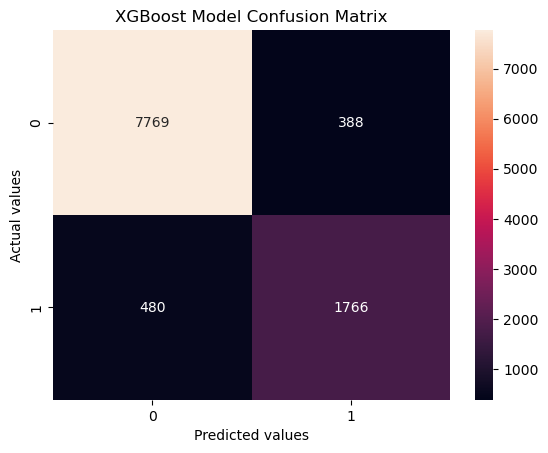

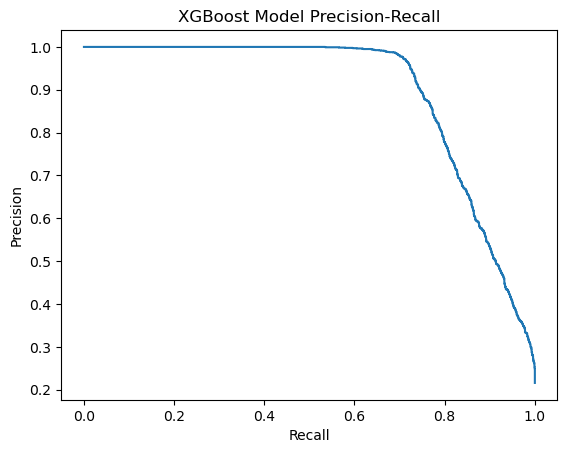

In [50]:
evaluate_model('XGBoost Model',xg_model,X_test,y_test)

In [36]:
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "Classifier__n_estimators": randint(150, 600),
    "Classifier__max_depth": randint(3, 9),
    "Classifier__learning_rate": uniform(0.01, 0.49),
    "Classifier__subsample": uniform(0.6, 0.4), #Rows sampling
    "Classifier__colsample_bytree": uniform(0.6, 0.4), #Column sampling
    "Classifier__min_child_weight": randint(1, 10),
    "Classifier__gamma": uniform(0, 5)
}

random_search = RandomizedSearchCV(
    estimator=xg_model,
    param_distributions=param_grid,
    n_iter=150,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('Preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_hist_length...
                                        'Classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000021FE0397D90>,
                                        'Classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000021FE3AD6BA0>,
                                        'Classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000021FE0397610>},
                   scoring='average_precision', verbose=1)

In [37]:
print(random_search.best_params_)
print()
print(random_search.best_score_)

{'Classifier__colsample_bytree': np.float64(0.7076630531618213), 'Classifier__gamma': np.float64(1.164629193463248), 'Classifier__learning_rate': np.float64(0.08231174076834255), 'Classifier__max_depth': 6, 'Classifier__min_child_weight': 5, 'Classifier__n_estimators': 324, 'Classifier__subsample': np.float64(0.9005305814927518)}

0.9011710662078762


XGBoost Model Metrices
Thresholds: 0.9997294545173645
Accuracy: 0.92
Recall: 0.79
Precision: 0.84
F1: 0.81

XGBoost Model Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      8157
           1       0.84      0.79      0.81      2246

    accuracy                           0.92     10403
   macro avg       0.89      0.88      0.88     10403
weighted avg       0.92      0.92      0.92     10403



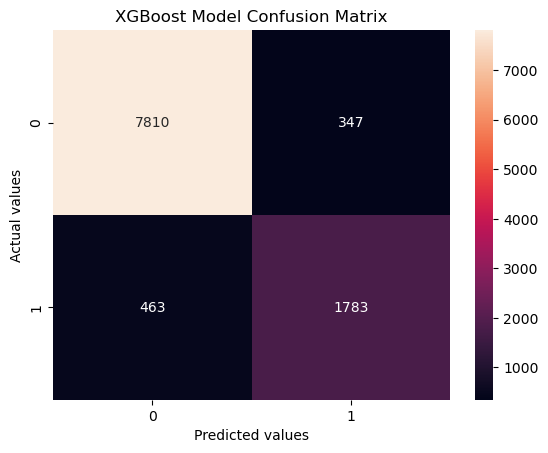

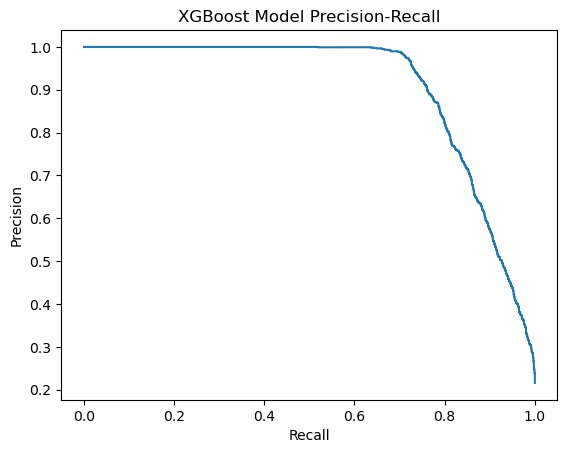

In [49]:
evaluate_model('XGBoost Model',random_search,X_test,y_test)

XGBoost Model Metrices
Thresholds: 0.9997294545173645
Accuracy: 0.78
Recall: 0.00
Precision: 0.00
F1: 0.00

XGBoost Model Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      8157
           1       0.00      0.00      0.00      2246

    accuracy                           0.78     10403
   macro avg       0.39      0.50      0.44     10403
weighted avg       0.61      0.78      0.69     10403



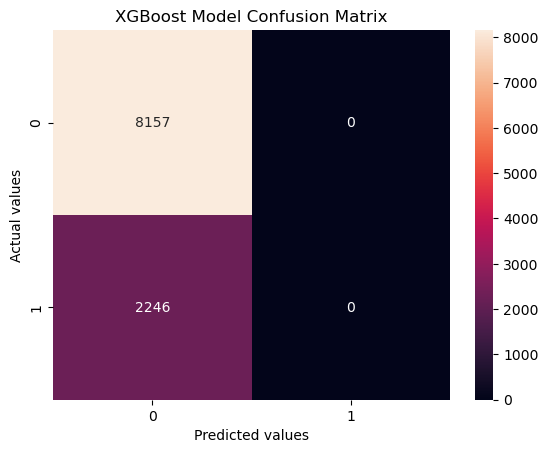

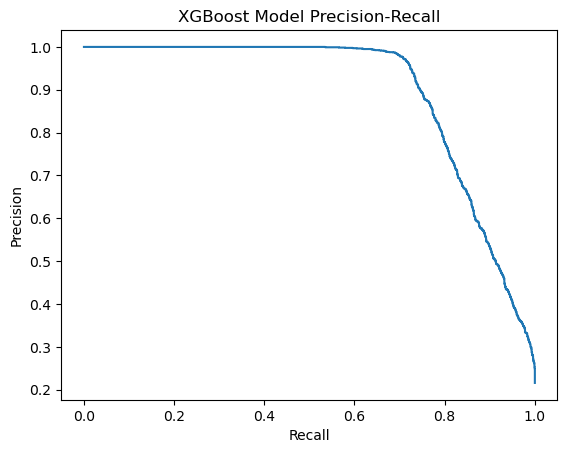

In [45]:
#Get the prob. of class 1 from XGBoost
prob = xg_model.predict_proba(X_test)[:,1]

#For each threshold calculate Precision and Recall
precisions,recalls,thresholds = precision_recall_curve(y_test,prob)

#Calculate F1 score for each threshold
f1 = 2*(precisions-recalls) / (precisions+recalls+1e-9)

#Get the threshold that produces the highest f1-score
best = np.argmax(f1[:-1])
best_threshold = thresholds[best]

#Evaluate the XGBoost model using that threshold
evaluate_model('XGBoost Model',xg_model,X_test,y_test,best_threshold)

In [96]:
#1. Calibrated XGBoost model
from sklearn.calibration import CalibratedClassifierCV,calibration_curve
best_model = random_search.best_estimator_
calibrated_model = CalibratedClassifierCV(
    best_model,
    method='sigmoid',
    cv=5
)
calibrated_model.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('Preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median'))]),
                                                                                   ['person_age',
                                                                                    'person_income',
                                                                                    'person_emp_length',
                                                                                    'loan_amnt',
                                                                                    'loan_int_rate',
                                                                                    'loan_percent_income',
                                                                                    'cb_person_cred_hist_length']),
                                                                                  ('cat',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer...
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=np.float64(0.08231174076834255),
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=6,
                                                                max_leaves=None,
                                                                min_child_weight=5,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=324,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]))

In [97]:
#2. Get Prob.
uncalibrated = xg_model.predict_proba(X_test)[:,1]
calibrated = calibrated_model.predict_proba(X_test)[:,1]
print(uncalibrated)
print()
print(calibrated)

[0.08779056 0.10345782 0.38989696 ... 0.06932039 0.24266548 0.9692629 ]

[0.02967528 0.02088711 0.10472227 ... 0.01672136 0.07882953 0.94324749]


In [98]:
#3. Create a Calibration curve
actual_uncal,predic_uncal = calibration_curve(y_test,uncalibrated,n_bins=10)
actual_cal,predic_cal = calibration_curve(y_test,calibrated,n_bins=10)

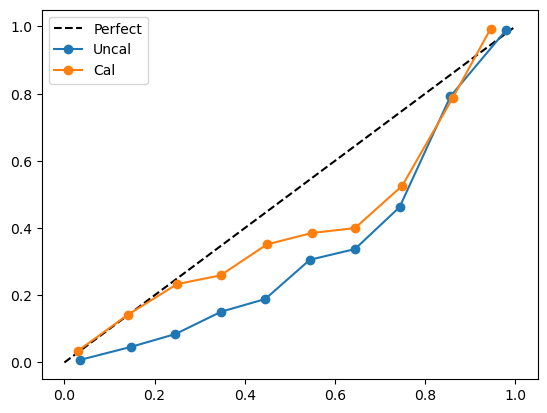

In [99]:
#4. Plot
plt.plot([0,1],[0,1],'k--',label='Perfect')
plt.plot(
    predic_uncal,
    actual_uncal,
    'o-',
    label = 'Uncal'
)

plt.plot(
    predic_cal,
    actual_cal,
    'o-',
    label = 'Cal'
)
plt.legend()

In [100]:
import shap

In [101]:
#1. Get the Trained XGboost classifier model out of the pipeline
xgb_classifier = xg_model.named_steps['Classifier']

In [102]:
#2. Transform X_test using the same preprocessing used for training.
X_test_trans = xg_model.named_steps['Preprocessor'].transform(X_test)

In [103]:
#3. Get the feature names after one-hot encoding, so plots are readable.
feature_names = xg_model.named_steps['Preprocessor'].get_feature_names_out()

In [104]:
#4. Convert to a dataframe for cleaner SHAP plots.
X_test_df = pd.DataFrame(X_test_trans,columns=feature_names)

In [105]:
#5. Create SHAP explainer built for tree-based model.
explainer = shap.TreeExplainer(xgb_classifier)

In [106]:
#6. Calculate SHAP values for every row in the test set
shap_values = explainer.shap_values(X_test_df)

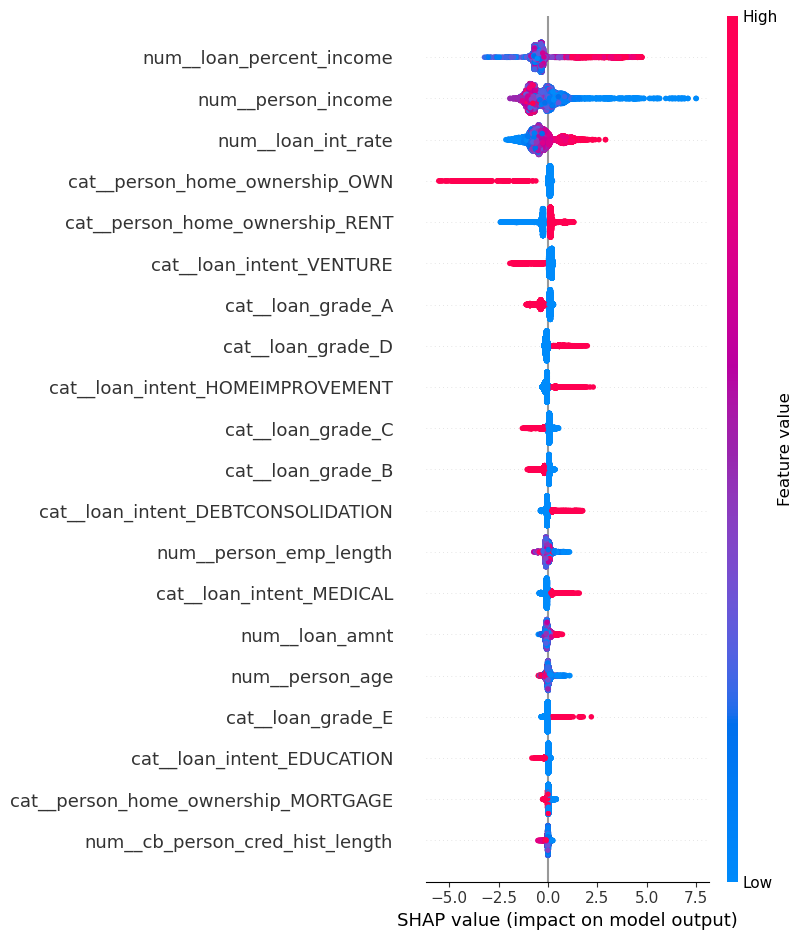

In [107]:
#Global:
shap.summary_plot(shap_values,X_test_df)

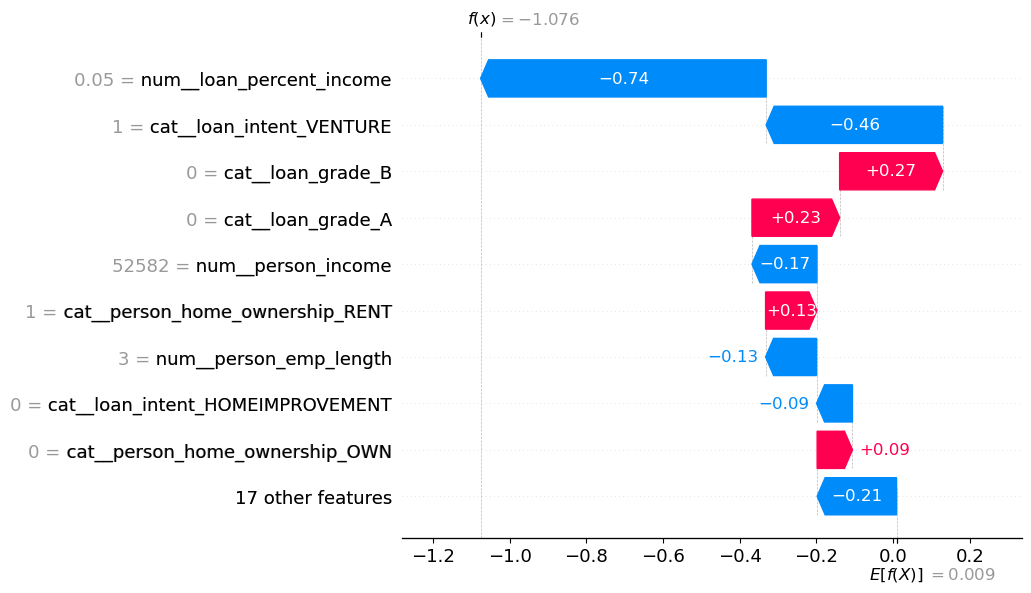

In [108]:
#Local:
#1. Pick one row to explain, e.g the 5th applicant in the test set
row_index = 5

#2.Draw a waterfall plot showing how each feature pushed the predic up or down
shap.plots.waterfall(
    shap.Explanation(
        values= shap_values[row_index],
        base_values= explainer.expected_value,
        data= X_test_df.iloc[row_index],
        feature_names= feature_names
    )
)

In [109]:
#Get predict from the best performing XGBoost model on the test set
y_pred = random_search.predict(X_test)

In [110]:
#Create a dataframe to easily compare the actual and predicted values
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred

In [111]:
# Identify false positive: model predicted 1 but actual was 0.
false_pos = result_df[(result_df['actual']==0) & (result_df['predicted']==1)]

# Identify false negative: model predicted 0 but actual was 1.
false_neg = result_df[(result_df['actual']==1) & (result_df['predicted']==0)]

print(f'False Positive: {len(false_pos)}')
print(f'False Negative: {len(false_neg)}')

False Positive: 347
False Negative: 463


In [112]:
#Export the Model:
import joblib
joblib.dump(calibrated_model,'credit_risk.pkl')

['credit_risk.pkl']

In [113]:
joblib.dump(best_threshold,'best_threshold.pkl')

['best_threshold.pkl']